In [1]:
import torch
from glob import glob
import os
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import transforms

# Device configuration
device = "cuda" if torch.cuda.is_available() else "cpu"

# Update dataset paths
# Update dataset paths
train_dir = r"C:\Users\Peddapalle Poojitha\Downloads\project file\Aerial Image Classification in Post Flood Scenarios Using Robust Deep Learning and Explainable Artificial Intelligence\CODE\BACKEND\dataset\auto drones\train"

val_dir = r"C:\Users\Peddapalle Poojitha\Downloads\project file\Aerial Image Classification in Post Flood Scenarios Using Robust Deep Learning and Explainable Artificial Intelligence\CODE\BACKEND\dataset\auto drones\valid"


# Set image size
image_size = (224, 224)

# Transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Custom Dataset class
class CustomDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_paths = glob(os.path.join(self.folder_path, '*', '*.jpg')) + \
                           glob(os.path.join(self.folder_path, '*', '*.jpeg'))
        self.labels = [self.get_label(path) for path in self.image_paths]
        self.labels_to_index = {label: index for index, label in enumerate(sorted(set(self.labels)))}

    def __getitem__(self, index):
        img_path = self.image_paths[index]
        img = Image.open(img_path).convert('RGB')
        label = self.labels[index]
        label_index = self.labels_to_index[label]

        if self.transform:
            img = self.transform(img)

        return img, label_index

    def __len__(self):
        return len(self.image_paths)

    def get_label(self, path):
        return os.path.basename(os.path.dirname(path))

# Load datasets
train_dataset = CustomDataset(train_dir, transform=train_transform)
val_dataset = CustomDataset(val_dir, transform=val_transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Dataset info
print(device)
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Class to index mapping: {train_dataset.labels_to_index}")


cpu
Training set size: 3600
Validation set size: 900
Class to index mapping: {'building': 0, 'flooded': 1, 'forest': 2, 'mountains': 3, 'sea': 4, 'street': 5}


c:\Users\Peddapalle Poojitha\.conda\envs\env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Peddapalle Poojitha\.conda\envs\env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train Loss: 0.3795, Train Acc: 87.53%, Val Loss: 0.1294, Val Acc: 95.22%
Epoch 2: Train Loss: 0.1669, Train Acc: 94.14%, Val Loss: 0.1159, Val Acc: 95.67%
Epoch 3: Train Loss: 0.1478, Train Acc: 94.75%, Val Loss: 0.1211, Val Acc: 95.22%
Epoch 4: Train Loss: 0.1263, Train Acc: 95.83%, Val Loss: 0.1145, Val Acc: 96.44%
Epoch 5: Train Loss: 0.0868, Train Acc: 96.92%, Val Loss: 0.1331, Val Acc: 95.44%
Epoch 6: Train Loss: 0.0727, Train Acc: 97.75%, Val Loss: 0.1328, Val Acc: 96.56%
Epoch 7: Train Loss: 0.0642, Train Acc: 97.92%, Val Loss: 0.2061, Val Acc: 93.33%
Epoch 8: Train Loss: 0.0548, Train Acc: 98.47%, Val Loss: 0.2100, Val Acc: 94.00%
Epoch 9: Train Loss: 0.0774, Train Acc: 97.58%, Val Loss: 0.1444, Val Acc: 94.22%
Epoch 10: Train Loss: 0.0560, Train Acc: 98.53%, Val Loss: 0.1251, Val Acc: 95.00%
Epoch 11: Train Loss: 0.0547, Train Acc: 98.11%, Val Loss: 0.1386, Val Acc: 94.33%


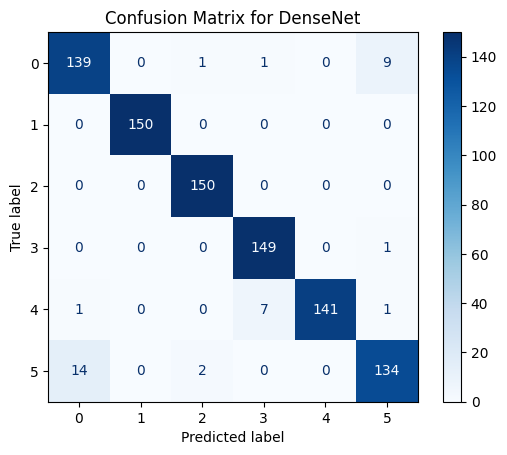

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       150
           1       1.00      1.00      1.00       150
           2       0.98      1.00      0.99       150
           3       0.95      0.99      0.97       150
           4       1.00      0.94      0.97       150
           5       0.92      0.89      0.91       150

    accuracy                           0.96       900
   macro avg       0.96      0.96      0.96       900
weighted avg       0.96      0.96      0.96       900



In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Model definition
class DenseNetModel(nn.Module):
    def __init__(self, num_classes):
        super(DenseNetModel, self).__init__()
        self.densenet = models.densenet121(pretrained=True)  # Using DenseNet-121
        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Linear(num_features, num_classes)  # Replace classifier with custom output layer

    def forward(self, x):
        return self.densenet(x)

# Initialize the model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenseNetModel(num_classes=6).to(device)  # Set num_classes appropriately
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0002)

def train_epoch():
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for batch in train_loader:
        data = batch[0].to(device)
        labels = batch[1].to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_predictions += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    accuracy = correct_predictions / total_predictions
    return avg_loss, accuracy

def eval_model(loader):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch in loader:
            data = batch[0].to(device)
            labels = batch[1].to(device)
            outputs = model(data)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_predictions += (preds == labels).sum().item()
            total_predictions += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct_predictions / total_predictions
    return avg_loss, accuracy

# Main training loop
best_score = float("inf")
n_epochs = 20
tolerance = 0

for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch()
    val_loss, val_acc = eval_model(val_loader)

    if val_loss < best_score:
        best_score = val_loss
        torch.save(model.state_dict(), "densenet.pt")
        tolerance = 0
    else:
        tolerance += 1
        if tolerance >= 8:
            break

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

# Generate predictions and true labels
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for batch in val_loader:
        data = batch[0].to(device)
        labels = batch[1].to(device)
        outputs = model(data)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for DenseNet")
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds))


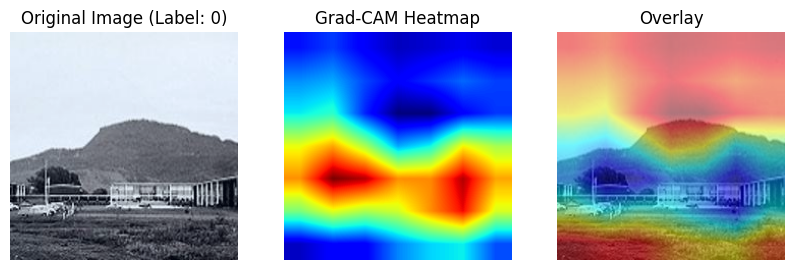

In [3]:
import cv2
import numpy as np 
# Grad-CAM Implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.feature_maps = None

        # Hook to capture feature maps
        self.target_layer.register_forward_hook(self.forward_hook)

    def forward_hook(self, module, input, output):
        self.feature_maps = output

    def generate_cam(self, input_tensor, class_idx):
        # Forward pass
        output = self.model(input_tensor)

        # Backward pass for the selected class
        self.model.zero_grad()
        one_hot = torch.zeros((1, output.size(-1)), dtype=torch.float32).to(input_tensor.device)
        one_hot[0, class_idx] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        # Calculate gradients manually
        gradients = torch.autograd.grad(outputs=output[:, class_idx],
                                         inputs=self.feature_maps,
                                         grad_outputs=torch.ones_like(output[:, class_idx]),
                                         retain_graph=True)[0]

        # Compute the Grad-CAM
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.feature_maps).sum(dim=1).squeeze(0)

        # Normalize and resize CAM
        cam = torch.relu(cam).detach().cpu().numpy()  # Use detach() before numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min())
        cam = cv2.resize(cam, (input_tensor.size(-1), input_tensor.size(-2)))

        return cam

# Select the target layer for Grad-CAM
target_layer = model.densenet.features[-1]  # Final convolutional layer
grad_cam = GradCAM(model, target_layer)

# Grad-CAM Visualization Function
def visualize_grad_cam(input_tensor, label, class_idx):
    input_tensor = input_tensor.unsqueeze(0).to(device)  # Add batch dimension
    cam = grad_cam.generate_cam(input_tensor, class_idx)

    # Convert tensor to image
    input_image = input_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    input_image = (input_image - input_image.min()) / (input_image.max() - input_image.min())
    input_image = np.uint8(255 * input_image)

    # Overlay heatmap on image
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(input_image, 0.5, heatmap, 0.5, 0)

    # Display the original image, heatmap, and overlay
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(input_image)
    plt.title(f"Original Image (Label: {label})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

# Example usage for Grad-CAM visualization
sample_data, sample_label = next(iter(val_loader))  # Take one batch
sample_data, sample_label = sample_data[0], sample_label[0]  # Take the first sample
predicted_class = model(sample_data.unsqueeze(0).to(device)).argmax(dim=1).item()

visualize_grad_cam(sample_data, sample_label.item(), predicted_class)


/tmp/ipykernel_31/1563957977.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("densenet.pt", map_location=device))


Predicted Class: Building


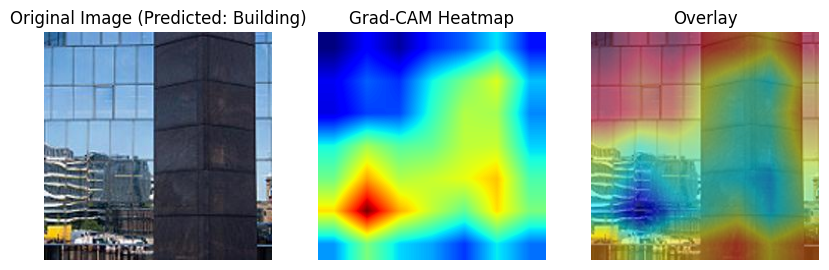

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Define the DenseNet model
class DenseNetModel(nn.Module):
    def __init__(self, num_classes):
        super(DenseNetModel, self).__init__()
        self.densenet = models.densenet121(pretrained=False)  # Ensure pretrained=False when loading a saved model
        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.densenet(x)

# Initialize model and load weights
device = "cuda" if torch.cuda.is_available() else "cpu"
model = DenseNetModel(num_classes=6).to(device)
model.load_state_dict(torch.load("densenet.pt", map_location=device))
model.eval()

# Define class names
class_names = ['Building', 'flooded', 'forest', 'mountains','sea',"street"]  # Replace with your actual class names

# Define image transformation
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Grad-CAM implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.feature_maps = None

        # Hook to capture feature maps
        self.target_layer.register_forward_hook(self.forward_hook)

    def forward_hook(self, module, input, output):
        self.feature_maps = output

    def generate_cam(self, input_tensor, class_idx):
        # Forward pass
        output = self.model(input_tensor)

        # Backward pass for the selected class
        self.model.zero_grad()
        one_hot = torch.zeros((1, output.size(-1)), dtype=torch.float32).to(input_tensor.device)
        one_hot[0, class_idx] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        # Calculate gradients manually
        gradients = torch.autograd.grad(outputs=output[:, class_idx],
                                         inputs=self.feature_maps,
                                         grad_outputs=torch.ones_like(output[:, class_idx]),
                                         retain_graph=True)[0]

        # Compute the Grad-CAM
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.feature_maps).sum(dim=1).squeeze(0)

        # Normalize and resize CAM
        cam = torch.relu(cam).detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min())
        cam = cv2.resize(cam, (input_tensor.size(-1), input_tensor.size(-2)))

        return cam

# Load and preprocess the image
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = image_transform(image).unsqueeze(0).to(device)
    return input_tensor, image

# Image path (update with the path to your test image)
image_path = "/kaggle/input/flooded-images/auto drones/valid/building/10210.jpg"

# Load the image
input_tensor, original_image = load_image(image_path)

# Predict the class
output = model(input_tensor)
predicted_class = output.argmax(dim=1).item()
predicted_class_name = class_names[predicted_class]
print(f"Predicted Class: {predicted_class_name}")

# Grad-CAM visualization
target_layer = model.densenet.features[-1]  # Final convolutional layer
grad_cam = GradCAM(model, target_layer)
cam = grad_cam.generate_cam(input_tensor, predicted_class)

# Convert input tensor to numpy image
input_image = input_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
input_image = (input_image - input_image.min()) / (input_image.max() - input_image.min())
input_image = np.uint8(255 * input_image)

# Overlay Grad-CAM heatmap
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
overlay = cv2.addWeighted(input_image, 0.5, heatmap, 0.5, 0)

# Display the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title(f"Original Image (Predicted: {predicted_class_name})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()


# MOBILENET

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 162MB/s]


Epoch 1: Train Loss: 0.3364, Train Acc: 89.06%, Val Loss: 0.1376, Val Acc: 94.67%
Epoch 2: Train Loss: 0.1746, Train Acc: 94.03%, Val Loss: 0.1383, Val Acc: 94.78%
Epoch 3: Train Loss: 0.1399, Train Acc: 95.03%, Val Loss: 0.1855, Val Acc: 93.33%
Epoch 4: Train Loss: 0.0938, Train Acc: 96.78%, Val Loss: 0.1178, Val Acc: 96.22%
Epoch 5: Train Loss: 0.0992, Train Acc: 96.19%, Val Loss: 0.1169, Val Acc: 95.67%
Epoch 6: Train Loss: 0.0997, Train Acc: 96.69%, Val Loss: 0.1133, Val Acc: 96.22%
Epoch 7: Train Loss: 0.0961, Train Acc: 96.67%, Val Loss: 0.1573, Val Acc: 94.89%
Epoch 8: Train Loss: 0.0865, Train Acc: 97.06%, Val Loss: 0.1400, Val Acc: 95.56%
Epoch 9: Train Loss: 0.0835, Train Acc: 97.17%, Val Loss: 0.1324, Val Acc: 94.78%
Epoch 10: Train Loss: 0.0837, Train Acc: 97.33%, Val Loss: 0.1451, Val Acc: 95.22%
Epoch 11: Train Loss: 0.0619, Train Acc: 97.72%, Val Loss: 0.1242, Val Acc: 96.44%
Epoch 12: Train Loss: 0.0511, Train Acc: 98.25%, Val Loss: 0.2896, Val Acc: 93.56%
Epoch 13: Tra

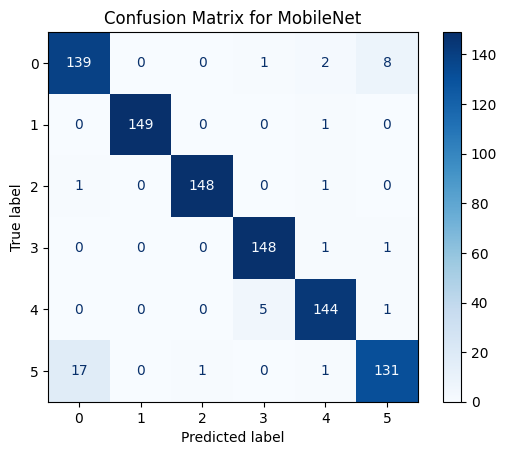

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       150
           1       1.00      0.99      1.00       150
           2       0.99      0.99      0.99       150
           3       0.96      0.99      0.97       150
           4       0.96      0.96      0.96       150
           5       0.93      0.87      0.90       150

    accuracy                           0.95       900
   macro avg       0.95      0.95      0.95       900
weighted avg       0.95      0.95      0.95       900



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Model definition (MobileNetV2)
class MobileNetModel(nn.Module):
    def __init__(self, num_classes):
        super(MobileNetModel, self).__init__()
        self.mobilenet = models.mobilenet_v2(pretrained=True)
        num_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier[1] = nn.Linear(num_features, num_classes)  # Replace final layer

    def forward(self, x):
        return self.mobilenet(x)

# Initialize the model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MobileNetModel(num_classes=6).to(device)  # Set num_classes appropriately
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0002)

def train_epoch():
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for batch in train_loader:
        data = batch[0].to(device)
        labels = batch[1].to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_predictions += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    accuracy = correct_predictions / total_predictions
    return avg_loss, accuracy

def eval_model(loader):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch in loader:
            data = batch[0].to(device)
            labels = batch[1].to(device)
            outputs = model(data)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_predictions += (preds == labels).sum().item()
            total_predictions += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct_predictions / total_predictions
    return avg_loss, accuracy

# Main training loop
best_score = float("inf")
n_epochs = 20
tolerance = 0

for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch()
    val_loss, val_acc = eval_model(val_loader)

    if val_loss < best_score:
        best_score = val_loss
        torch.save(model.state_dict(), "mobilenet.pt")
        tolerance = 0
    else:
        tolerance += 1
        if tolerance >= 8:
            break

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

# Generate predictions and true labels
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for batch in val_loader:
        data = batch[0].to(device)
        labels = batch[1].to(device)
        outputs = model(data)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for MobileNet")
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds))
